# 🧪 Evaluación de Creatividad Artificial con CLIP - 2025-07-04

Este notebook evalúa imágenes generadas previamente con IA (por ejemplo, Stable Diffusion, **DALL·E** o Midjourney) a partir de un prompt, aplicando métricas como CLIPScore y simetría para reflexionar sobre la creatividad y coherencia visual.

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install pillow numpy matplotlib scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-rb_wu2zb
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-rb_wu2zb
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import torch
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import pandas as pd


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


100%|███████████████████████████████████████| 338M/338M [00:11<00:00, 31.2MiB/s]


In [ ]:
# Crear carpeta
os.makedirs("imagenes_generadas", exist_ok=True)
print("Ya puedes cargar tus imagenes en la carpeta imagenes_generadas")

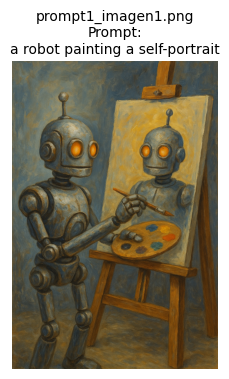

prompt1_imagen1.png (a robot painting a self-portrait): 0.3193


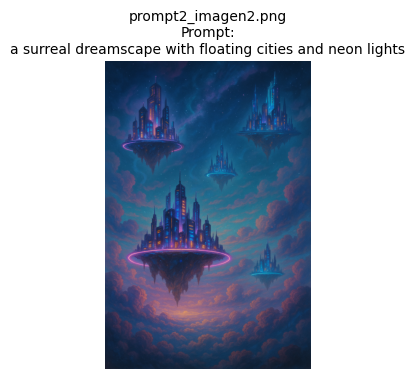

prompt2_imagen2.png (a surreal dreamscape with floating cities and neon lights): 0.3246


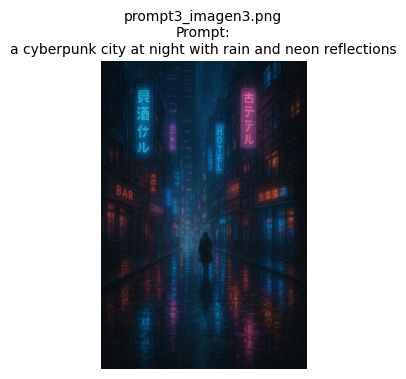

prompt3_imagen3.png (a cyberpunk city at night with rain and neon reflections): 0.3482


In [14]:
# Directorio con imágenes generadas y prompts
img_dir = "imagenes_generadas"
prompts_file = "imagenes_generadas/prompts.txt"

# prompts.txt debe tener líneas tipo: nombre_imagen.jpg | prompt asociado
results = []

import matplotlib.pyplot as plt

with open(prompts_file, "r", encoding="utf-8") as f:
    for line in f:
        if "|" not in line: continue
        filename, prompt = [x.strip() for x in line.split("|")]
        img_path = os.path.join(img_dir, filename)
        if not os.path.exists(img_path): continue

        # Mostrar imagen y prompt
        img = Image.open(img_path)
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{filename}\nPrompt:\n{prompt}", fontsize=10)
        plt.show()

        # Procesar imagen con CLIP
        image = preprocess(img).unsqueeze(0).to(device)
        text = clip.tokenize([prompt]).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)
            similarity = torch.cosine_similarity(image_features, text_features).item()

        results.append({
            "filename": filename,
            "prompt": prompt,
            "clip_score": similarity
        })

        print(f"{filename} ({prompt}): {similarity:.4f}")


In [ ]:
def calculate_symmetry(image_path):
    image = Image.open(image_path).convert("L")  # grayscale
    image_np = np.array(image)

    w = image_np.shape[1]
    left = image_np[:, :w//2]
    right = np.fliplr(image_np[:, w//2:])

    min_shape = (min(left.shape[0], right.shape[0]), min(left.shape[1], right.shape[1]))
    score, _ = ssim(left[:min_shape[0], :min_shape[1]], right[:min_shape[0], :min_shape[1]], full=True)
    return score

for r in results:
    r["symmetry"] = calculate_symmetry(os.path.join(img_dir, r["filename"]))
    print(f"{r['filename']} - Simetría: {r['symmetry']:.4f}")


prompt1_imagen1.png - Simetría: 0.2750
prompt2_imagen2.png - Simetría: 0.5661
prompt3_imagen3.png - Simetría: 0.5185


In [13]:
df = pd.DataFrame(results)
df_sorted = df.sort_values(by="clip_score", ascending=False)
df_sorted.reset_index(drop=True, inplace=True)
df_sorted


,filename,prompt,clip_score,symmetry
0,prompt3_imagen3.png,a cyberpunk city at night with rain and neon r...,0.348193,0.518489
1,prompt2_imagen2.png,a surreal dreamscape with floating cities and ...,0.324627,0.566127
2,prompt1_imagen1.png,a robot painting a self-portrait,0.319338,0.274982


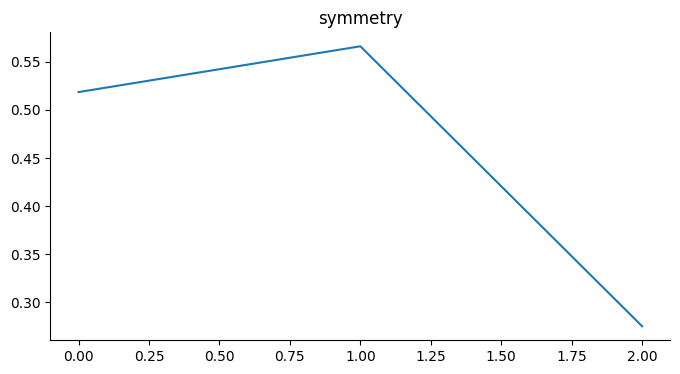

In [ ]:
from matplotlib import pyplot as plt
df_sorted['symmetry'].plot(kind='line', figsize=(8, 4), title='symmetry')
plt.gca().spines[['top', 'right']].set_visible(False)

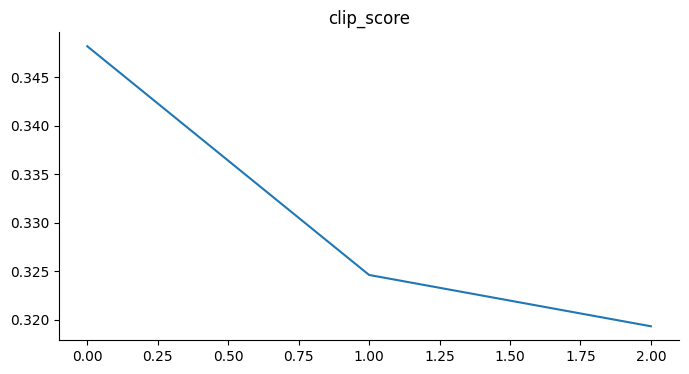

In [ ]:
from matplotlib import pyplot as plt
df_sorted['clip_score'].plot(kind='line', figsize=(8, 4), title='clip_score')
plt.gca().spines[['top', 'right']].set_visible(False)

## 📊 Análisis de Resultados

A continuación, se presentan los resultados obtenidos tras evaluar las imágenes generadas con las métricas **CLIPScore** (alineación semántica entre prompt e imagen) y **simetría** (balance visual entre lados izquierdo y derecho):

| Filename              | Prompt                                                   | CLIPScore | Simetría |
|-----------------------|-----------------------------------------------------------|-----------|----------|
| prompt3_imagen3.png   | a cyberpunk city at night with rain and neon reflections  | **0.348** | 0.518    |
| prompt2_imagen2.png   | a surreal dreamscape with floating cities and neon lights | 0.325     | **0.566**|
| prompt1_imagen1.png   | a robot painting a self-portrait                           | 0.319     | 0.275    |

---

### 🔍 Interpretación métrica

#### 1. **CLIPScore** (alineación entre texto e imagen):
- **Mayor puntuación:** `imagen3` con un valor de 0.348, lo cual indica que representa de forma más precisa el contenido del prompt “a cyberpunk city at night with rain and neon reflections”.
- **Menor puntuación:** `imagen1` (0.319), posiblemente porque la relación visual entre un "robot" y un "autorretrato" puede ser más ambigua o difícil de representar claramente.

#### 2. **Simetría visual**:
- **Mayor simetría:** `imagen2` (0.566), lo que puede sugerir una composición más balanceada, con elementos distribuidos de forma armónica en ambos lados de la imagen.
- **Menor simetría:** `imagen1` (0.275), probablemente debido a un enfoque visual más cargado hacia un solo lado (por ejemplo, un robot pintando).

---

### 📌 Interpretación combinada

| Imagen    | ¿Mejor alineada? | ¿Más simétrica? | Interpretación |
|-----------|------------------|-----------------|----------------|
| imagen3   | ✅                | Moderada        | Buena alineación con el prompt y balance visual aceptable. |
| imagen2   | 🟡                | ✅              | Gran balance visual, aunque no tan alineada semánticamente. |
| imagen1   | ❌                | ❌              | Podría ser más creativa o compleja, pero menos clara visualmente. |

---

### 💭 Reflexión

Aunque la imagen 1 obtuvo las puntuaciones más bajas en ambas métricas, podría ser la más interesante desde una perspectiva artística si representa un concepto más abstracto o subjetivo como un “robot pintando un autorretrato”.

Esto nos recuerda que:

- **Las métricas no capturan completamente la creatividad.**
- La evaluación humana sigue siendo indispensable para interpretar aspectos subjetivos como el estilo, la originalidad o el impacto emocional.
- La imagen 3 destaca por su coherencia visual y semántica, lo cual puede ser ideal para usos prácticos (como ilustraciones conceptuales o diseño gráfico).

Si bien estas métricas nos permiten evaluar ciertos aspectos técnicos como la alineación semántica (CLIPScore) o el balance visual (simetría), **no logran capturar la dimensión humana de la creatividad**.

Desde mi perspectiva, estas métricas indican qué tan bien está “construida” una imagen en relación con su prompt, pero **no reflejan su potencial creativo, emocional o expresivo**.

Por tanto, **los resultados obtenidos no son concluyentes desde un punto de vista subjetivo o artístico**. La creatividad es un fenómeno que va más allá de la lógica matemática o visual, y sigue requiriendo de la sensibilidad y juicio humano para ser verdaderamente comprendida y valorada.
